In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
all_data_df = pd.read_csv('/workspaces/py_spec/Lysozyme/26-02-20 15-59-11 Em Scan 295.CSV', skiprows=5)
print(all_data_df.head())
print(f"\nDataframe shape: {all_data_df.shape}")
print(f"\nColumn names (first 10): {all_data_df.columns.tolist()[:10]}")

  Well          Content  \
0  NaN  Wavelength [nm]   
1  B01        Sample X1   
2  B02        Sample X2   
3  B03        Sample X3   
4  B04        Sample X4   

   Average over replicates based on Blank corrected (Em Spectrum)  \
0                                              340.0                
1                                           161821.7                
2                                           139742.0                
3                                            95937.3                
4                                           123467.7                

   Average over replicates based on Blank corrected (Em Spectrum).1  \
0                                              341.0                  
1                                           157423.9                  
2                                           136054.4                  
3                                            93402.7                  
4                                           120486.7               

In [5]:
# Get the column names
columns = all_data_df.columns.tolist()

# Find where each section starts based on the column headers
avg_blank_corrected_cols = [i for i, col in enumerate(columns) if 'Average over replicates' in str(col) and 'Blank corrected' in str(col)]
blank_corrected_cols = [i for i, col in enumerate(columns) if 'Blank corrected based on Raw Data' in str(col)]
raw_data_cols = [i for i, col in enumerate(columns) if 'Raw Data' in str(col) and 'Blank corrected' not in str(col)]

# Extract metadata columns (Well, Content)
metadata_cols = [0, 1]

# Create separate dataframes
# Average blank corrected
avg_blank_corrected_df = all_data_df.iloc[:, metadata_cols + avg_blank_corrected_cols].copy()
avg_blank_corrected_df.columns = ['Well', 'Content'] + [f'nm_{340+i}' for i in range(len(avg_blank_corrected_cols))]

# Blank corrected
blank_corrected_df = all_data_df.iloc[:, metadata_cols + blank_corrected_cols].copy()
blank_corrected_df.columns = ['Well', 'Content'] + [f'nm_{340+i}' for i in range(len(blank_corrected_cols))]

# Raw data
raw_df = all_data_df.iloc[:, metadata_cols + raw_data_cols].copy()
raw_df.columns = ['Well', 'Content'] + [f'nm_{340+i}' for i in range(len(raw_data_cols))]

print(f"Average blank corrected shape: {avg_blank_corrected_df.shape}")
print(f"Blank corrected shape: {blank_corrected_df.shape}")
print(f"Raw data shape: {raw_df.shape}")
print("\nAverage blank corrected preview:")
print(avg_blank_corrected_df.head())
print("\nBlank corrected preview:")
print(blank_corrected_df.head())

Average blank corrected shape: (37, 403)
Blank corrected shape: (37, 403)
Raw data shape: (37, 403)

Average blank corrected preview:
  Well          Content    nm_340    nm_341    nm_342    nm_343    nm_344  \
0  NaN  Wavelength [nm]     340.0     341.0     342.0     343.0     344.0   
1  B01        Sample X1  161821.7  157423.9  151078.0  145103.6  139489.8   
2  B02        Sample X2  139742.0  136054.4  130514.2  125539.2  120358.1   
3  B03        Sample X3   95937.3   93402.7   89542.0   85739.2   82430.1   
4  B04        Sample X4  123467.7  120486.7  115193.7  110773.4  106371.5   

     nm_345    nm_346    nm_347  ...  nm_731        nm_732  nm_733  \
0     345.0     346.0     347.0  ...   731.0  7.320000e+02   733.0   
1  132945.3  126451.5  119750.3  ...    35.0  1.520000e-13   -38.6   
2  114747.3  108978.9  103605.9  ...     0.0 -3.660000e+01   -38.6   
3   78566.6   74322.7   70779.8  ...     0.0  1.520000e-13   -77.1   
4  101283.5   96351.2   91566.5  ...    35.0  1.52000

In [6]:
# Create concentration mapping for samples
concentration_map = {
    'Sample X1': 10.0,
    'Sample X2': 9.0,
    'Sample X3': 8.0,
    'Sample X4': 7.0,
    'Sample X5': 6.0,
    'Sample X6': 5.0,
    'Sample X7': 4.0,
    'Sample X8': 3.0,
    'Sample X9': 2.0,
    'Sample X10': 1.0,
    'Sample X11': 0.1,
    'Sample X12': 0.0  # Blank
}

# Replace Content column with concentration values
blank_corrected_df['Content'] = blank_corrected_df['Content'].map(concentration_map)

print("Blank corrected data with concentrations:")
print(blank_corrected_df[['Well', 'Content']].head(15))
print(f"\nFull dataframe shape: {blank_corrected_df.shape}")
print("\nPreview of data:")
print(blank_corrected_df.head())

Blank corrected data with concentrations:
   Well  Content
0   NaN      NaN
1   B01     10.0
2   B02      9.0
3   B03      8.0
4   B04      7.0
5   B05      6.0
6   B06      5.0
7   B07      4.0
8   B08      3.0
9   B09      2.0
10  B10      1.0
11  B11      0.1
12  B12      NaN
13  C01     10.0
14  C02      9.0

Full dataframe shape: (37, 403)

Preview of data:
  Well  Content    nm_340    nm_341    nm_342    nm_343    nm_344    nm_345  \
0  NaN      NaN     340.0     341.0     342.0     343.0     344.0     345.0   
1  B01     10.0  195141.0  189301.0  181376.0  174430.0  167342.0  159425.0   
2  B02      9.0  154459.0  150034.0  144018.0  138423.0  132272.0  125977.0   
3  B03      8.0  158119.0  153648.0  147587.0  140691.0  135111.0  128765.0   
4  B04      7.0  129262.0  126136.0  119960.0  115490.0  110610.0  105193.0   

     nm_346    nm_347  ...  nm_731  nm_732  nm_733  nm_734  nm_735  nm_736  \
0     346.0     347.0  ...   731.0   732.0   733.0   734.0   735.0   736.0   
1  1

In [7]:
# Extract wavelengths and create plotting dataframe
# For emission spectra, the wavelengths start at 340 nm and go to 740 nm
num_wavelengths = blank_corrected_df.shape[1] - 2  # Exclude Well and Content columns
wavelengths = np.linspace(340, 740, num_wavelengths)

print(f"Number of wavelengths: {len(wavelengths)}")
print(f"Wavelength range: {wavelengths[0]} to {wavelengths[-1]} nm")

# Create column names that match the ones in blank_corrected_df
wavelength_cols = [f'nm_{340+i}' for i in range(len(wavelengths))]

# Create a dataframe for plotting with Content and wavelength columns
plot_data = blank_corrected_df[['Content'] + wavelength_cols].copy()

# Group by concentration and calculate mean and std between replicates
grouped = plot_data.groupby('Content')
mean_spectra = grouped.mean()
std_spectra = grouped.std()

# Create a long-format dataframe for plotting with wavelengths, content, and SD
content_idx_map = {content: idx for idx, content in enumerate(mean_spectra.index)}

plot_df_list = []
for content in mean_spectra.index:
    content_idx = content_idx_map[content]
    for i, wl in enumerate(wavelengths):
        plot_df_list.append({
            'wavelength': wl,
            'content': content,
            'mean': mean_spectra.iloc[content_idx, i],
            'std': std_spectra.iloc[content_idx, i]
        })

plot_for_plotting = pd.DataFrame(plot_df_list)

print("\nDataframe for plotting:")
print(plot_for_plotting.head(20))
print(f"\nShape: {plot_for_plotting.shape}")
print(f"\nUnique concentrations: {sorted(plot_for_plotting['content'].unique())}")

Number of wavelengths: 401
Wavelength range: 340.0 to 740.0 nm

Dataframe for plotting:
    wavelength  content         mean          std
0        340.0      0.1  4765.333333  1191.153363
1        341.0      0.1  4659.666667  1164.993705
2        342.0      0.1  4446.666667  1106.981632
3        343.0      0.1  4267.000000  1055.983428
4        344.0      0.1  4083.666667  1009.043772
5        345.0      0.1  3872.000000   958.868604
6        346.0      0.1  3668.333333   906.452610
7        347.0      0.1  3484.000000   854.831562
8        348.0      0.1  3297.000000   799.719951
9        349.0      0.1  3118.666667   763.507913
10       350.0      0.1  2969.666667   722.695879
11       351.0      0.1  2791.000000   685.106561
12       352.0      0.1  2636.000000   649.546765
13       353.0      0.1  2497.666667   619.497646
14       354.0      0.1  2376.333333   589.111478
15       355.0      0.1  2284.333333   572.049240
16       356.0      0.1  2216.666667   538.585493
17       357

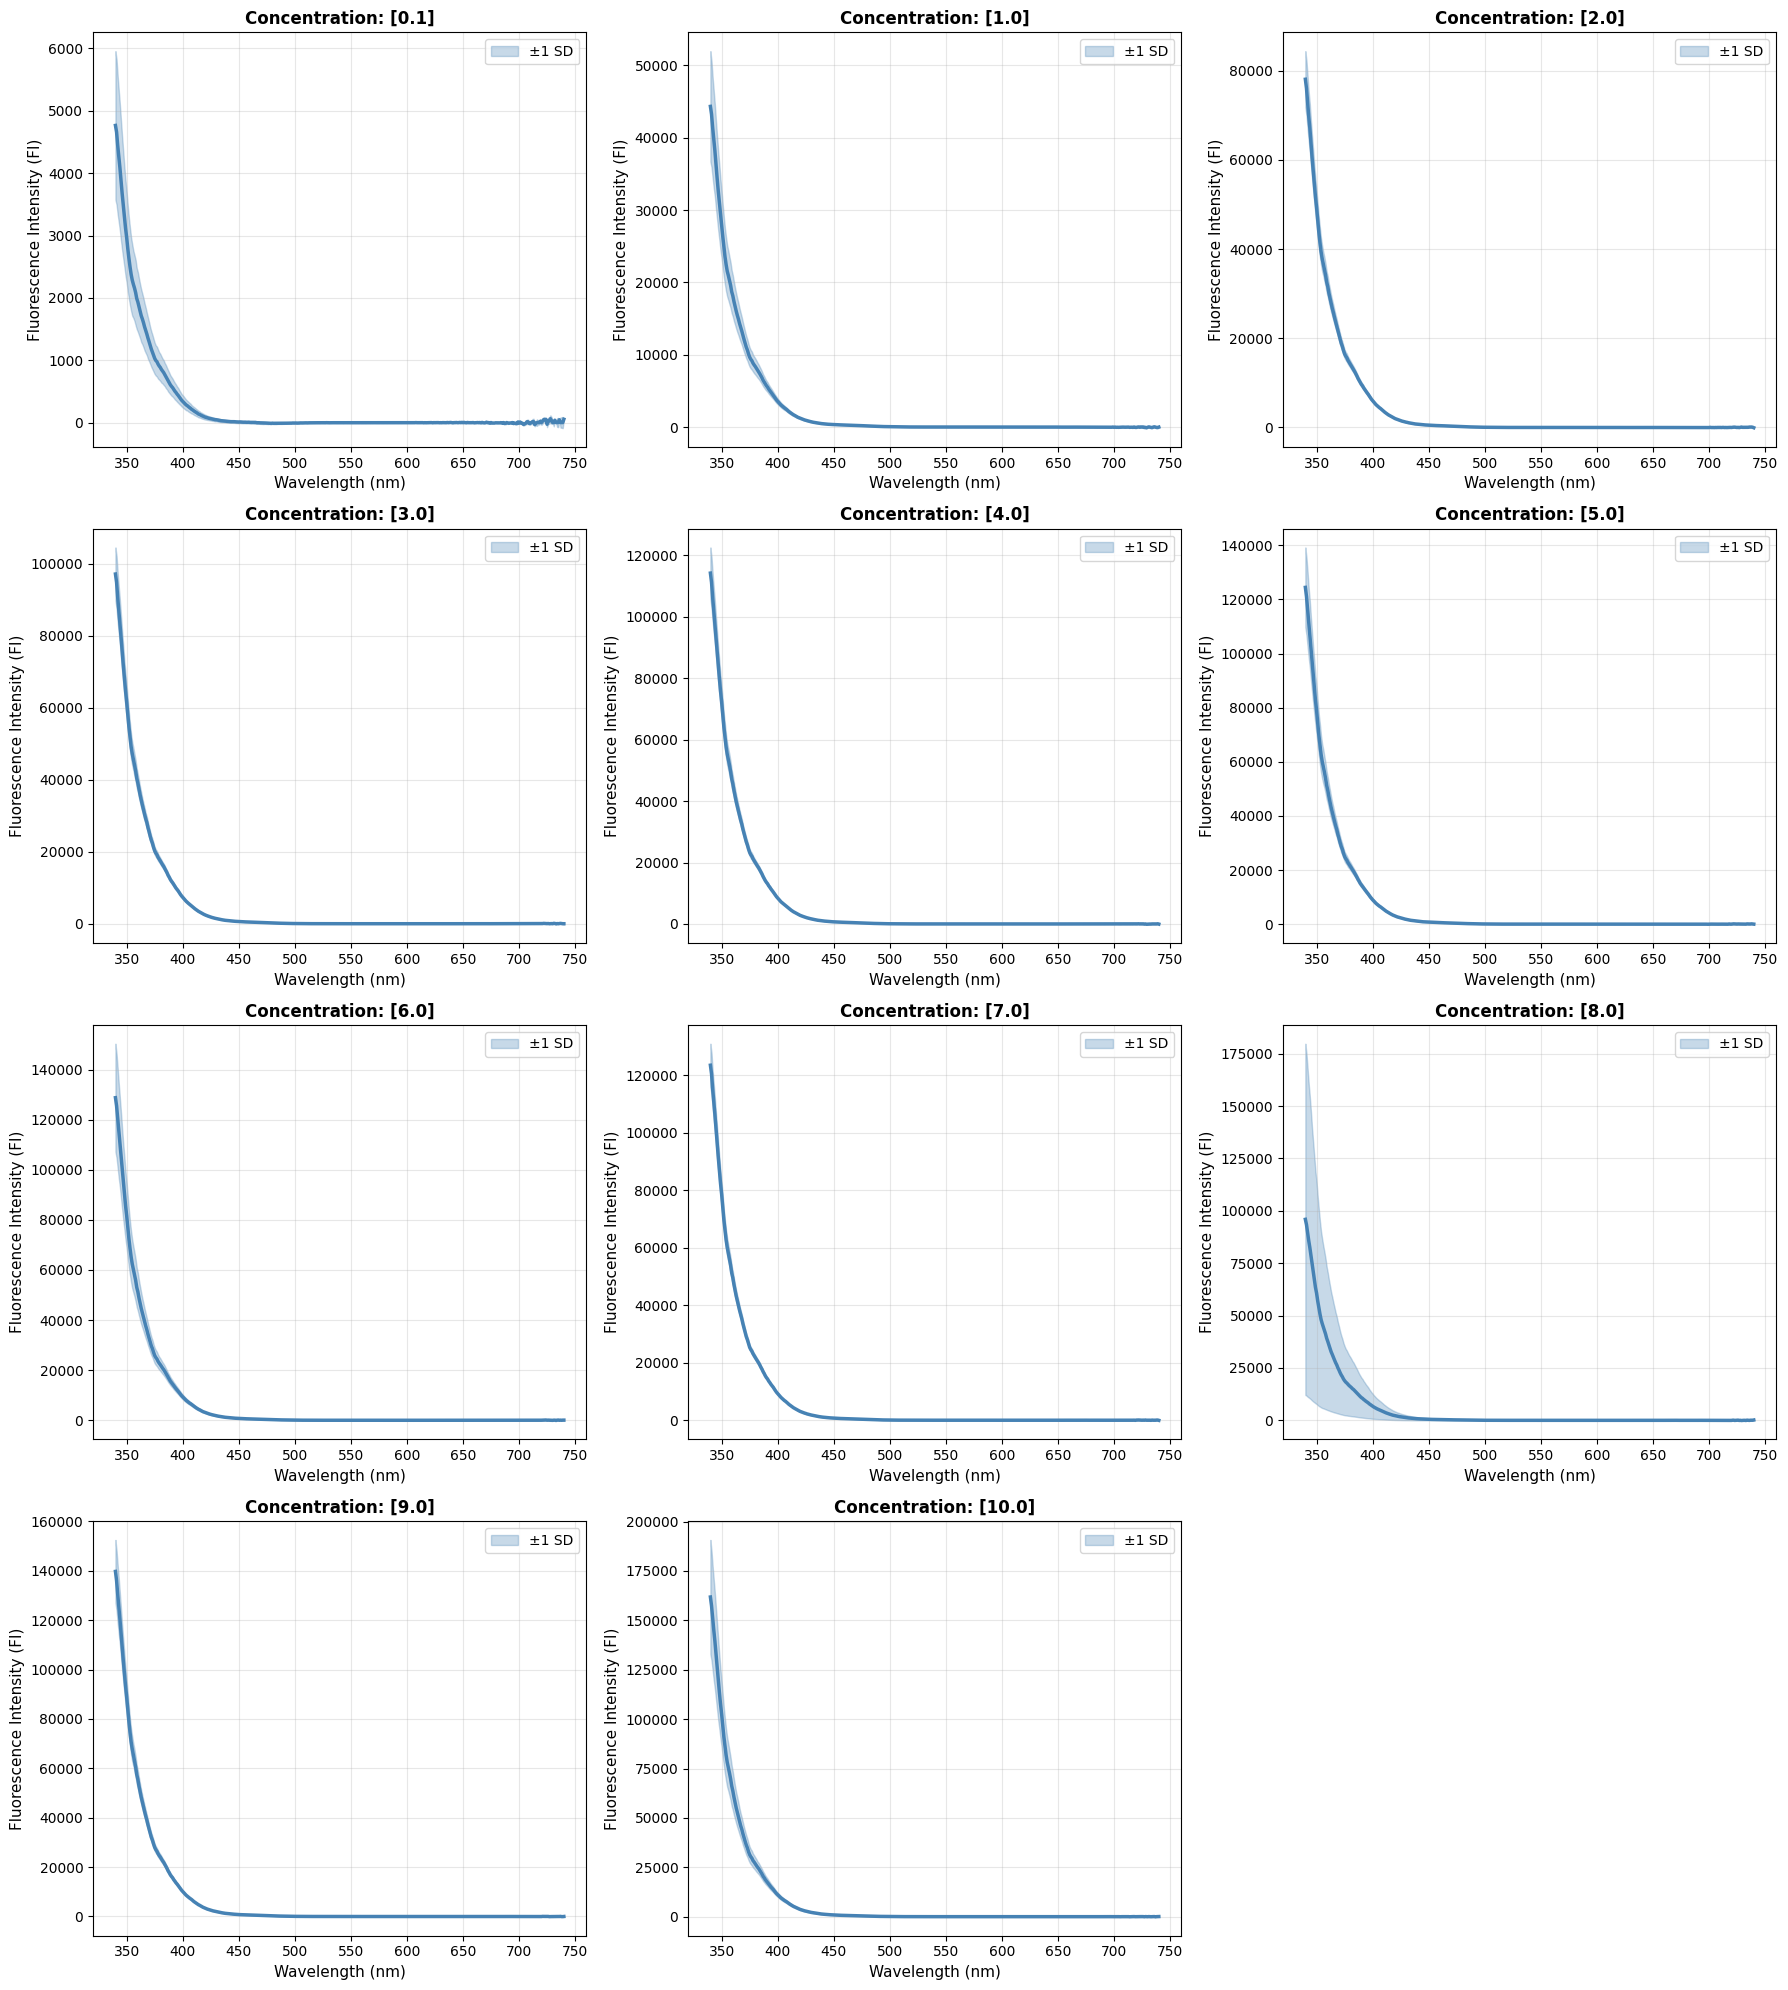

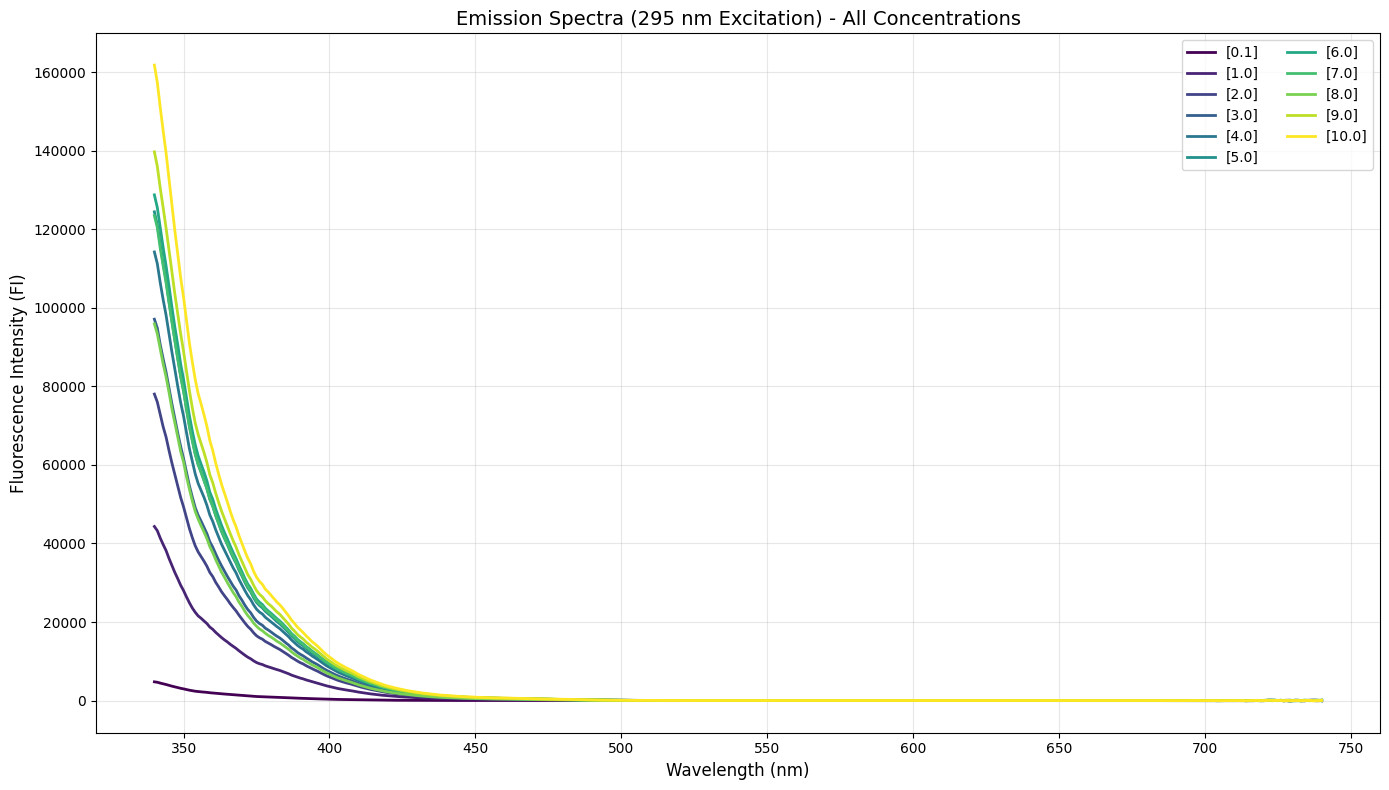

In [8]:
# Create individual plots for each concentration
concentrations = sorted(plot_for_plotting['content'].unique())
n_plots = len(concentrations)

# Create subplots for individual concentrations
fig_individual, axes = plt.subplots(n_rows := (n_plots + 2) // 3, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, conc in enumerate(concentrations):
    conc_data = plot_for_plotting[plot_for_plotting['content'] == conc].sort_values('wavelength')
    
    wavelengths_plot = conc_data['wavelength'].values
    mean_plot = conc_data['mean'].values
    std_plot = conc_data['std'].values
    
    ax = axes[idx]
    
    # Plot mean line
    ax.plot(wavelengths_plot, mean_plot, color='steelblue', linewidth=2.5)
    
    # Plot SD as shadow band
    ax.fill_between(wavelengths_plot, 
                     mean_plot - std_plot, 
                     mean_plot + std_plot, 
                     alpha=0.3, 
                     color='steelblue',
                     label='±1 SD')
    
    ax.set_xlabel('Wavelength (nm)', fontsize=11)
    ax.set_ylabel('Fluorescence Intensity (FI)', fontsize=11)
    ax.set_title(f'Concentration: [{conc}]', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

# Remove extra subplots
for idx in range(n_plots, len(axes)):
    fig_individual.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Create overlay plot with all concentrations (no SD bands)
fig_overlay, ax_overlay = plt.subplots(figsize=(14, 8))

colors_overlay = plt.cm.viridis(np.linspace(0, 1, len(concentrations)))

for idx, conc in enumerate(concentrations):
    conc_data = plot_for_plotting[plot_for_plotting['content'] == conc].sort_values('wavelength')
    
    wavelengths_plot = conc_data['wavelength'].values
    mean_plot = conc_data['mean'].values
    
    # Plot mean line only
    ax_overlay.plot(wavelengths_plot, mean_plot, label=f'[{conc}]', 
                    color=colors_overlay[idx], linewidth=2)

ax_overlay.set_xlabel('Wavelength (nm)', fontsize=12)
ax_overlay.set_ylabel('Fluorescence Intensity (FI)', fontsize=12)
ax_overlay.set_title('Emission Spectra (295 nm Excitation) - All Concentrations', fontsize=14)
ax_overlay.legend(loc='best', fontsize=10, ncol=2)
ax_overlay.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

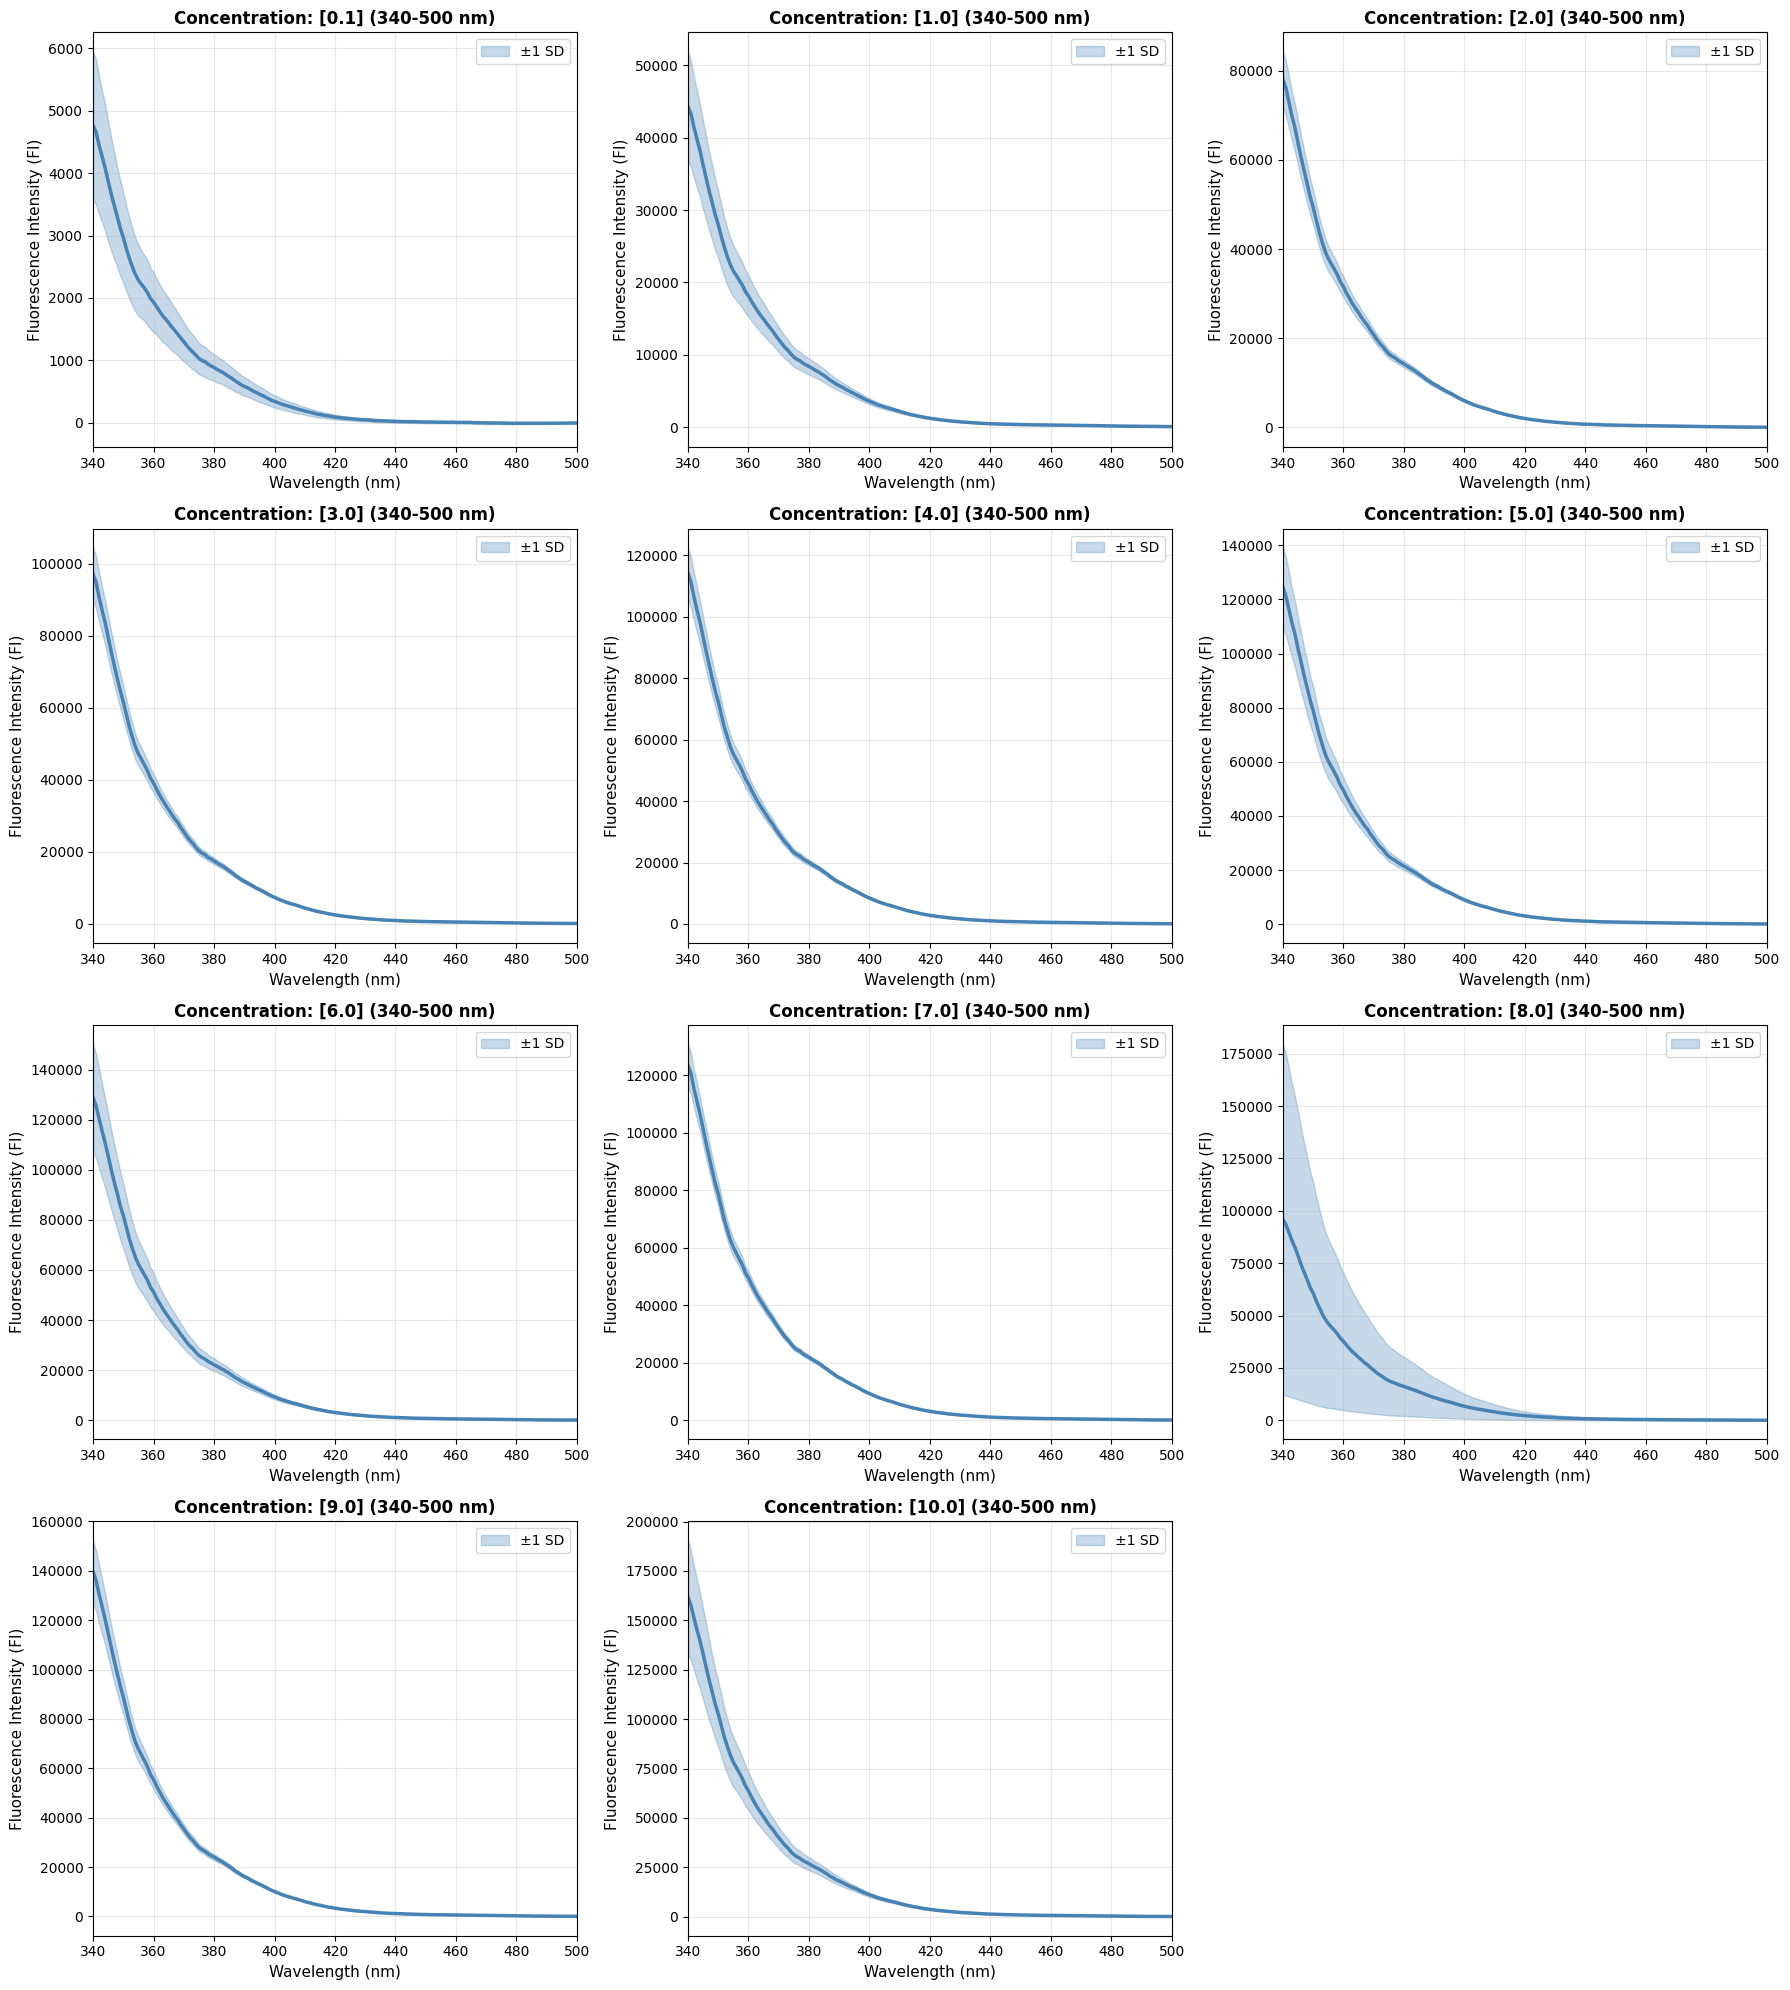

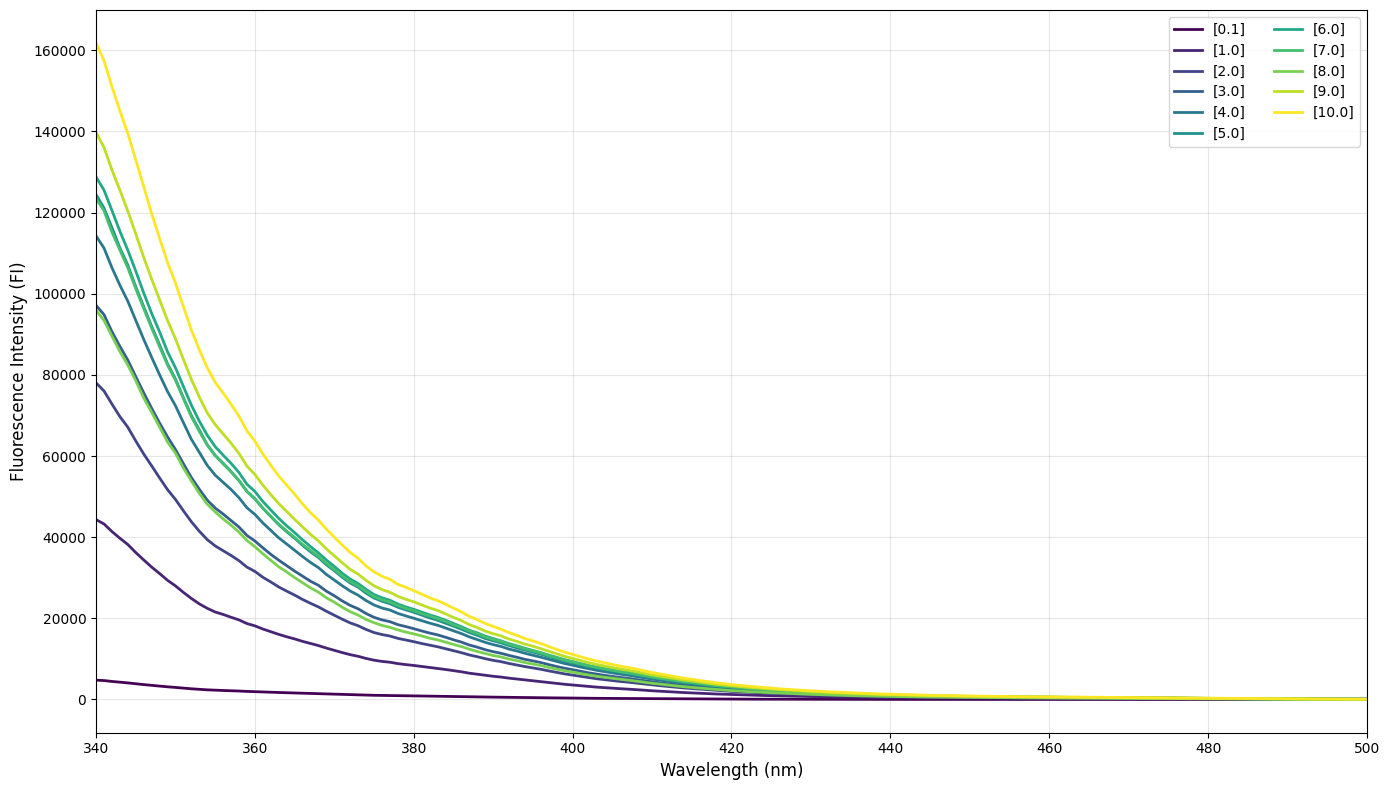

In [10]:
# Create individual plots for each concentration - ZOOMED TO 340-500 nm
fig_individual_zoom, axes_zoom = plt.subplots(n_rows := (n_plots + 2) // 3, 3, figsize=(18, 5 * n_rows))
axes_zoom = axes_zoom.flatten()

for idx, conc in enumerate(concentrations):
    conc_data = plot_for_plotting[plot_for_plotting['content'] == conc].sort_values('wavelength')
    
    wavelengths_plot = conc_data['wavelength'].values
    mean_plot = conc_data['mean'].values
    std_plot = conc_data['std'].values
    
    ax = axes_zoom[idx]
    
    # Plot mean line
    ax.plot(wavelengths_plot, mean_plot, color='steelblue', linewidth=2.5)
    
    # Plot SD as shadow band
    ax.fill_between(wavelengths_plot, 
                     mean_plot - std_plot, 
                     mean_plot + std_plot, 
                     alpha=0.3, 
                     color='steelblue',
                     label='±1 SD')
    
    ax.set_xlabel('Wavelength (nm)', fontsize=11)
    ax.set_ylabel('Fluorescence Intensity (FI)', fontsize=11)
    ax.set_title(f'Concentration: [{conc}] (340-500 nm)', fontsize=12, fontweight='bold')
    ax.set_xlim(340, 500)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

# Remove extra subplots
for idx in range(n_plots, len(axes_zoom)):
    fig_individual_zoom.delaxes(axes_zoom[idx])

plt.tight_layout()
plt.show()

# Create overlay plot with all concentrations - ZOOMED TO 340-500 nm
fig_overlay_zoom, ax_overlay_zoom = plt.subplots(figsize=(14, 8))

colors_overlay = plt.cm.viridis(np.linspace(0, 1, len(concentrations)))

for idx, conc in enumerate(concentrations):
    conc_data = plot_for_plotting[plot_for_plotting['content'] == conc].sort_values('wavelength')
    
    wavelengths_plot = conc_data['wavelength'].values
    mean_plot = conc_data['mean'].values
    
    # Plot mean line only
    ax_overlay_zoom.plot(wavelengths_plot, mean_plot, label=f'[{conc}]', 
                         color=colors_overlay[idx], linewidth=2)

ax_overlay_zoom.set_xlabel('Wavelength (nm)', fontsize=12)
ax_overlay_zoom.set_ylabel('Fluorescence Intensity (FI)', fontsize=12)
ax_overlay_zoom.set_title('', fontsize=14)
ax_overlay_zoom.set_xlim(340, 500)
ax_overlay_zoom.legend(loc='best', fontsize=10, ncol=2)
ax_overlay_zoom.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()